In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

## Generating data 

Text(0.5, 1.0, 'Data points')

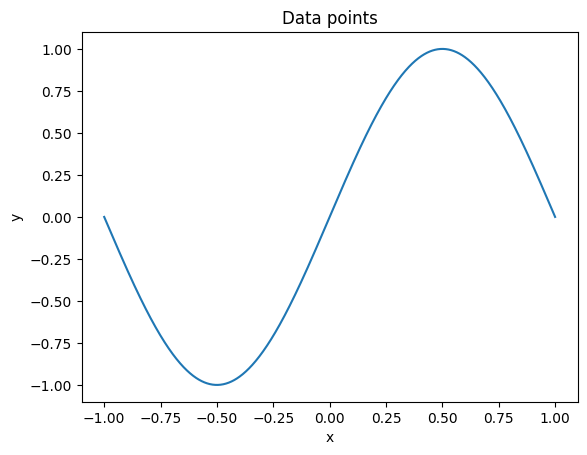

In [3]:
N = 1000
x = np.linspace(-1,1,N)
y = np.sin(np.pi*x)
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data points')

## DEsign matrix builder

In [1]:
# Dynamically building polynomial functions. 

def design_matrix(x, degree):

    X = np.ones((len(x), degree+1))
    
    for i in range(1, degree + 1):
        X[:,i] = x ** i
    
    return X

## Gradient Descent Function 

In [3]:
def gradient_descent(X, y, lr = 0.01, tol = 1e-4 , max_iter=100000):
    n, d = X.shape
    theta = np.zeros(0)

    prev_loss = np.inf
    start_time = time.time()

    for i in range(max_iter):
        y_pred = X @ theta
        error = y_pred - y
        loss = np.mean(error**2) # MSE

        if abs(prev_loss-loss) < tol:
            print("Convergence at iteration : " , i)
            break

        grad = (2/n) * (X.T @ error)
        theta = theta - lr * grad

        prev_loss = loss
    runtime = time.time() - start_time
    return theta, loss, i+1, runtime



In [ ]:
def condition_number(X):
    return np.linalg.cond(X.T @ X)

## Experiment

In [ ]:
degress = range(1,21)

tolerances = [1e-2, 1e-4, 1e-6]

results = []

for tol in tolerances:
    for deg in degress:

        X = design_matrix(x, deg)

        cond = condition_number(X)
        theta, loss, iters, runtime = gradient_descent(
            X,
            y,
            lr=0.01,
            tol=tol
        )

        results.append({
            "degree":deg,
            "tolerance" : tol,
            "final_mse":loss,
            "iterations":iters,
            "runtime": runtime,
            "condition_number":cond

        })

print(f"deg={deg}, tol={tol}, mse={loss:.2e}, iters={iters}, cond={cond:.2e}")


NameError: name 'x' is not defined